In [33]:
# language: python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import (load_breast_cancer, load_wine, load_iris,
                             load_digits, load_diabetes)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score


In [34]:
# --- تنظیمات ظاهری و رنگ‌ها ---
class TextColors:
    BLUE = '\033[94m'   # برای KNN
    GREEN = '\033[92m'  # برای Naive Bayes
    RED = '\033[91m'    # برای Decision Tree
    CYAN = '\033[96m'   # برای حالت تساوی (Draw)
    BOLD = '\033[1m'
    RESET = '\033[0m'
    YELLOW_BG = '\033[43m\033[30m'

# نگاشت نام مدل به رنگ متن کنسول
model_text_mapping = {
    'KNN': TextColors.BLUE,
    'Naive Bayes': TextColors.GREEN,
    'Decision Tree': TextColors.RED
}

# پالت رنگی نمودارها (ثابت)
chart_palette = {
    'KNN': '#1f77b4',       # آبی
    'Naive Bayes': '#2ca02c', # سبز
    'Decision Tree': '#d62728' # قرمز
}


In [35]:
# --- آماده‌سازی داده‌ها ---
datasets = {
    'Breast Cancer': load_breast_cancer(),
    'Wine': load_wine(),
    'Iris': load_iris(),
    'Digits': load_digits(),
    'Diabetes': load_diabetes()
}

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42)
}

full_database = []


In [36]:
# --- حلقه اصلی پردازش (Training & Evaluation) ---
for data_name, data_obj in datasets.items():
    X, y = data_obj.data, data_obj.target

    # تبدیل Diabetes به باینری برای امکان مقایسه
    if data_name == 'Diabetes':
        y = (y > np.median(y)).astype(int)

    # تقسیم داده‌ها
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42
        )
    except ValueError:
        # اگر stratify ممکن نبود (مثلا در حجم کم)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    # استانداردسازی
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # آموزش و ارزیابی مدل‌ها
    for model_name, model_inst in models.items():
        model_inst.fit(X_train, y_train)
        y_pred = model_inst.predict(X_test)
        
        full_database.append({
            'Dataset': data_name,
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1-Score': f1_score(y_test, y_pred, average='macro')
        })


In [37]:
# --- بخش ۱: گزارش متنی پیشرفته (با قابلیت تشخیص تساوی) ---
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics_list:
    print(f"\n{TextColors.YELLOW_BG} >>> WINNERS BY {metric.upper()} <<< {TextColors.RESET}")
    # عرض ستون نام مدل را بیشتر کردیم تا حالت تساوی جا شود
    print(f"{'Dataset':<15} | {'Winner Model(s)':<35} | {metric:<10}")
    print("-" * 65)
    
    for d_name in datasets.keys():
        dataset_records = [r for r in full_database if r['Dataset'] == d_name]
        
        # پیدا کردن بالاترین نمره
        max_score = max(r[metric] for r in dataset_records)
        
        # پیدا کردن تمام مدل‌هایی که نمره‌شان برابر با ماکزیمم است (با در نظر گرفتن خطای اعشاری)
        winners = [r for r in dataset_records if abs(r[metric] - max_score) < 1e-9]
        winner_names = [w['Model'] for w in winners]
        
        if len(winner_names) > 1:
            # حالت تساوی: نمایش همه نام‌ها و رنگ فیروزه‌ای
            display_name = " & ".join(winner_names)
            color = TextColors.CYAN
        else:
            # حالت تک برنده
            display_name = winner_names[0]
            color = model_text_mapping.get(display_name, TextColors.RESET)
        
        print(f"{color}{TextColors.BOLD}"
              f"{d_name:<15} | {display_name:<35} | {max_score:.4f}"
              f"{TextColors.RESET}")
    print("\n")



 >>> WINNERS BY ACCURACY <<< 
Dataset         | Winner Model(s)                     | Accuracy  
-----------------------------------------------------------------
Breast Cancer   | KNN                                 | 0.9561
Wine            | KNN & Naive Bayes                   | 0.9722
Iris            | Naive Bayes                         | 0.9667
Digits          | KNN                                 | 0.9639
Diabetes        | KNN                                 | 0.7528



 >>> WINNERS BY PRECISION <<< 
Dataset         | Winner Model(s)                     | Precision 
-----------------------------------------------------------------
Breast Cancer   | KNN                                 | 0.9551
Wine            | Naive Bayes                         | 0.9744
Iris            | Naive Bayes                         | 0.9697
Digits          | KNN                                 | 0.9646
Diabetes        | KNN                                 | 0.7528



 >>> WINNERS BY RECALL <<< 
Dataset 

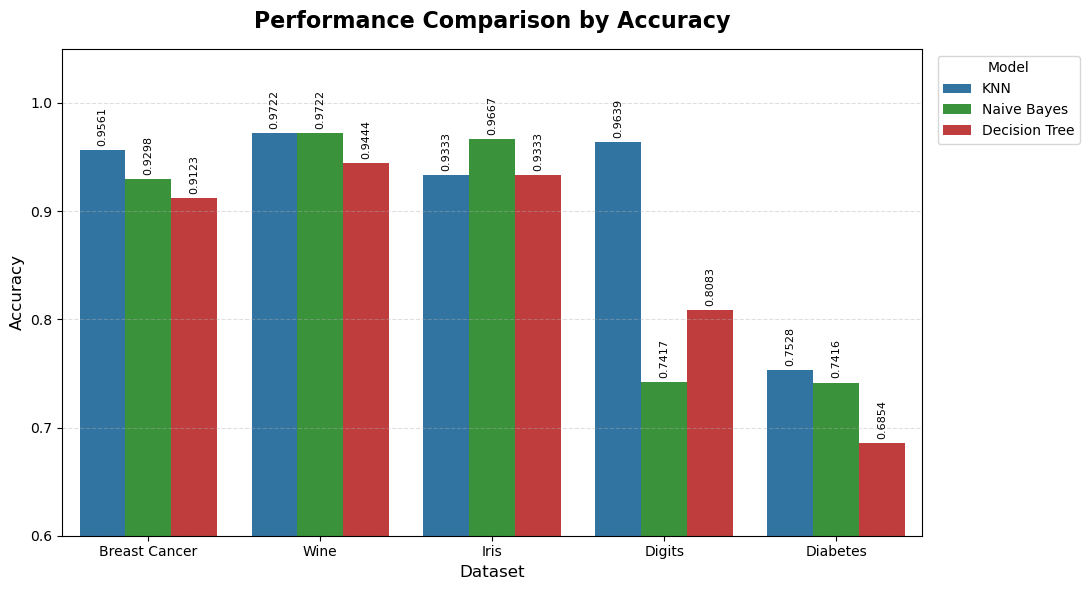

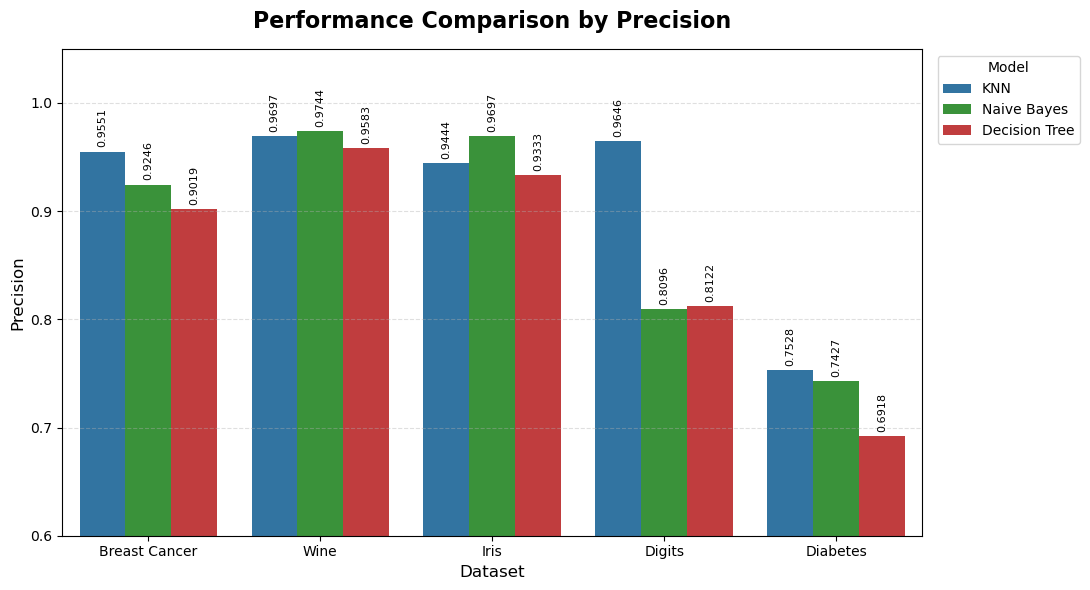

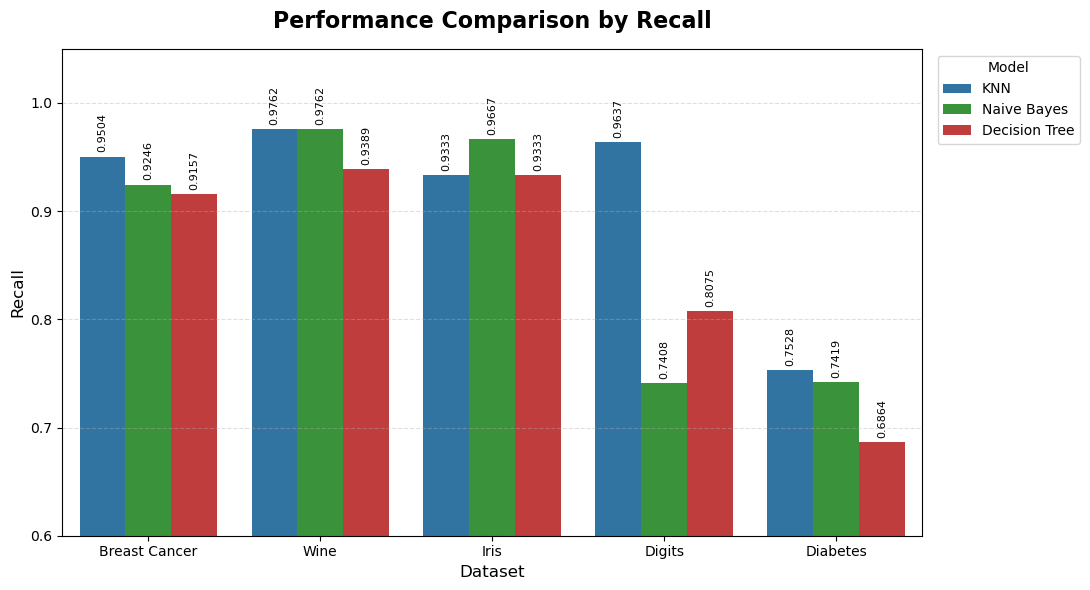

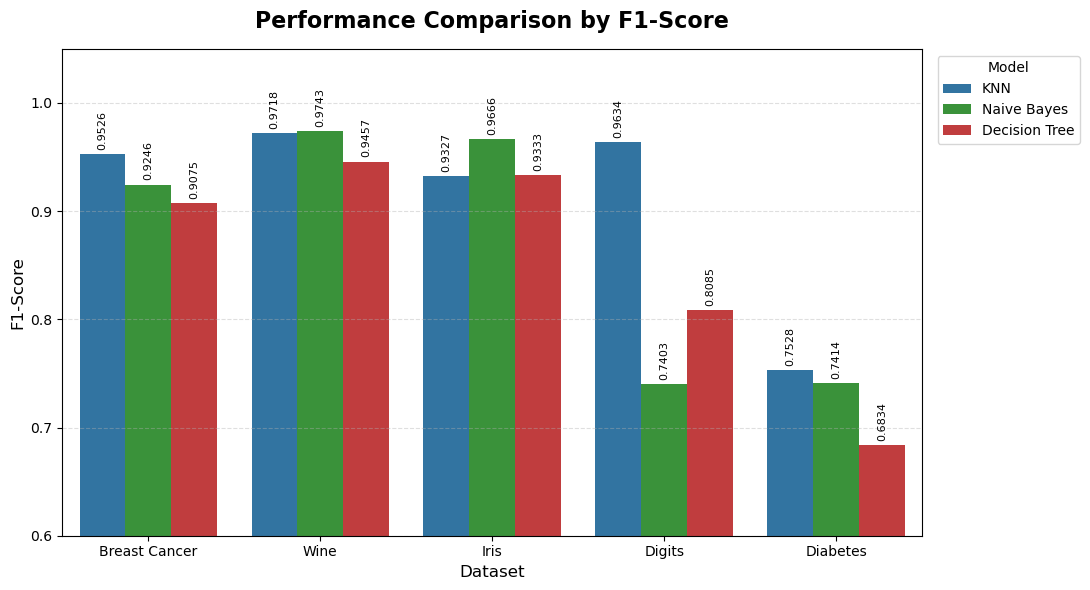

In [38]:
# --- بخش ۲: رسم نمودارهای مجزا ---
df_results = pd.DataFrame(full_database)

for metric in metrics_list:
    plt.figure(figsize=(11, 6)) # ایجاد پنجره جدید برای هر نمودار
    
    ax = sns.barplot(
        data=df_results, 
        x='Dataset', 
        y=metric, 
        hue='Model', 
        palette=chart_palette
    )
    
    plt.title(f'Performance Comparison by {metric}', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Dataset', fontsize=12)
    plt.ylim(0.6, 1.05) # فضای کافی برای اعداد و لجند
    
    # تنظیم لجند
    plt.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # نمایش اعداد روی میله‌ها با 4 رقم اعشار
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3, fontsize=8, rotation=90)
    
    plt.tight_layout()
    plt.show()
